# Exploratory Data Analysis (EDA) on Processed Data
This notebook explores the cleaned and split dataset to understand class distributions, stratification, and text statistics. This is crucial before moving to model training.

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid")
plt.rcParams.update({'figure.max_open_warning': 0})


## 1. Load Data
We load the train, validation, and test sets from `data/processed/`.

In [14]:
data_dir = '../data/processed'
train_df = pd.read_csv(f"{data_dir}/train.csv")
val_df = pd.read_csv(f"{data_dir}/val.csv")
test_df = pd.read_csv(f"{data_dir}/test.csv")

print(f"Train size: {len(train_df)}")
print(f"Validation size: {len(val_df)}")
print(f"Test size: {len(test_df)}")


Train size: 1018
Validation size: 528
Test size: 528


## 3. Distribution of NFR Subcategories
Let's look at the distribution of the `sub_NFR` categories within the Train set.

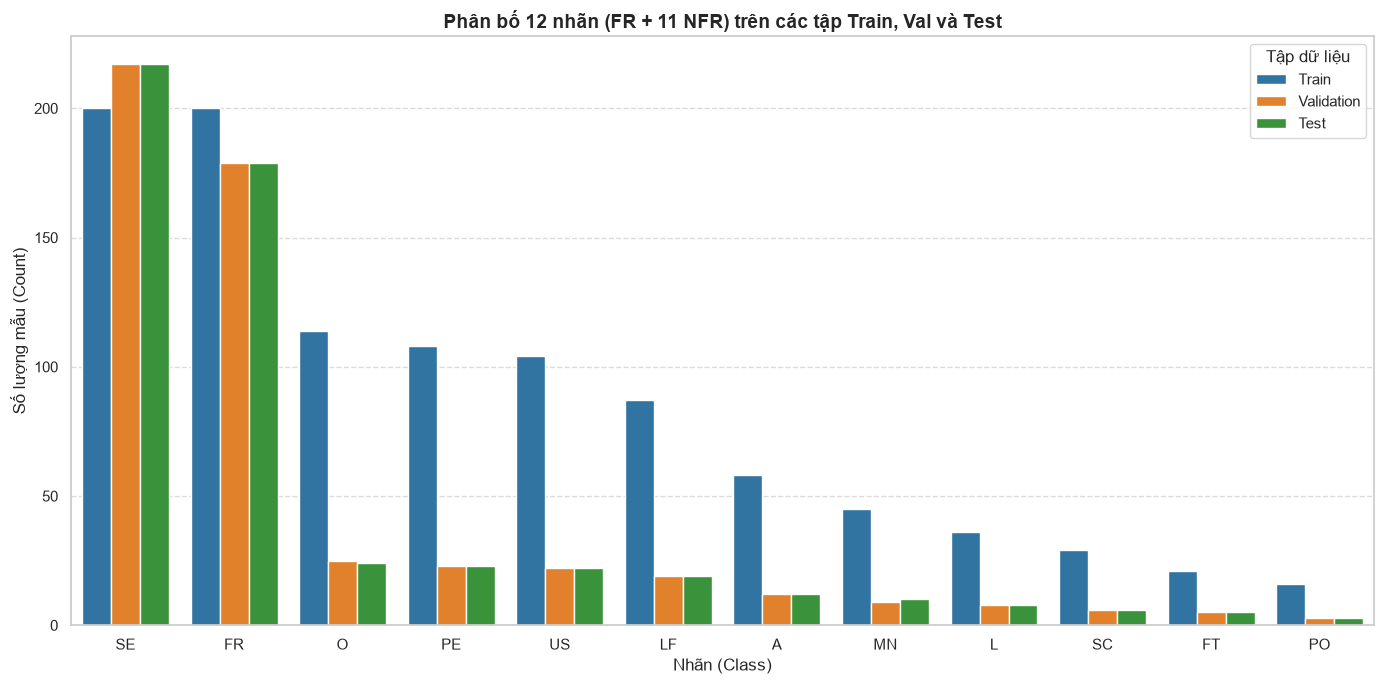


--- BẢNG THỐNG KÊ CHI TIẾT ---
Split  Train  Validation  Test  Total
label                                
SE       200         217   217    634
FR       200         179   179    558
O        114          25    24    163
PE       108          23    23    154
US       104          22    22    148
LF        87          19    19    125
A         58          12    12     82
MN        45           9    10     64
L         36           8     8     52
SC        29           6     6     41
FT        21           5     5     31
PO        16           3     3     22


In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Nếu bạn chạy trực tiếp trên Colab với file cùng thư mục thì đổi data_dir = '.'
data_dir = '../data/processed' 

train_df = pd.read_csv(f"{data_dir}/train.csv")
val_df = pd.read_csv(f"{data_dir}/val.csv")
test_df = pd.read_csv(f"{data_dir}/test.csv")

# Gắn nhãn cho từng tập dữ liệu
train_df['Split'] = 'Train'
val_df['Split'] = 'Validation'
test_df['Split'] = 'Test'

# Gộp chung lại thành 1 DataFrame tổng để dễ vẽ
all_df = pd.concat([train_df, val_df, test_df], ignore_index=True)

# Sắp xếp các nhãn theo tổng số lượng giảm dần
order = all_df['label'].value_counts().index

# Bắt đầu vẽ biểu đồ
plt.figure(figsize=(14, 7))
sns.countplot(
    data=all_df, 
    x='label', 
    hue='Split', 
    order=order, 
    palette=['#1f77b4', '#ff7f0e', '#2ca02c'] # Xanh dương, Cam, Xanh lá
)

plt.title("Phân bố 12 nhãn (FR + 11 NFR) trên các tập Train, Val và Test", fontsize=14, fontweight='bold')
plt.xlabel("Nhãn (Class)", fontsize=12)
plt.ylabel("Số lượng mẫu (Count)", fontsize=12)

# Hiển thị lưới mờ cho dễ nhìn số
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Tập dữ liệu')

plt.tight_layout()
plt.show()

# (Tùy chọn) In ra bảng thống kê số liệu chính xác
print("\n--- BẢNG THỐNG KÊ CHI TIẾT ---")
summary_table = pd.crosstab(all_df['label'], all_df['Split'])
summary_table = summary_table[['Train', 'Validation', 'Test']] # Sắp xếp lại thứ tự cột
summary_table['Total'] = summary_table.sum(axis=1)
summary_table = summary_table.sort_values('Total', ascending=False)
print(summary_table)



## 4. Text Length Analysis
Understanding the length of the requirements helps in setting the `max_length` parameter for BERT/ELECTRA models.

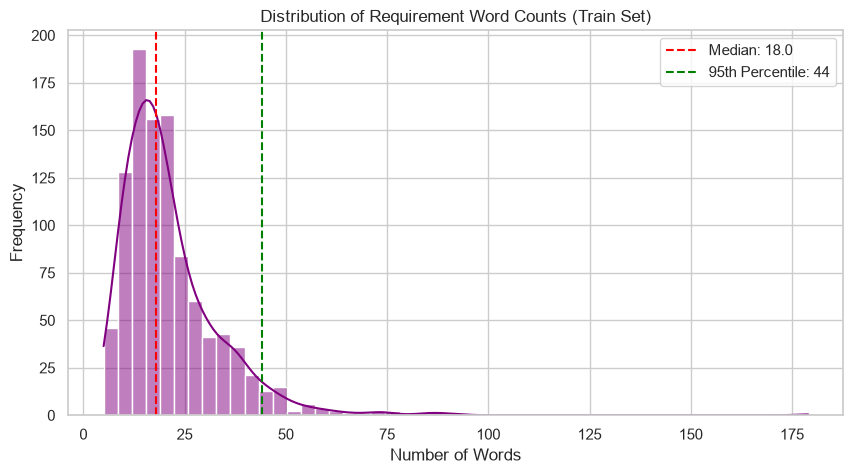

In [16]:
train_df['word_count'] = train_df['text'].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(10, 5))
sns.histplot(train_df['word_count'], bins=50, kde=True, color='purple')
plt.title("Distribution of Requirement Word Counts (Train Set)")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.axvline(train_df['word_count'].median(), color='red', linestyle='--', label=f"Median: {train_df['word_count'].median()}")
plt.axvline(train_df['word_count'].quantile(0.95), color='green', linestyle='--', label=f"95th Percentile: {int(train_df['word_count'].quantile(0.95))}")
plt.legend()
plt.show()


In [17]:
print("Word Count Statistics (Train Set):")
print(train_df['word_count'].describe())


Word Count Statistics (Train Set):
count    1018.000000
mean       21.339882
std        12.756644
min         5.000000
25%        13.000000
50%        18.000000
75%        25.000000
max       179.000000
Name: word_count, dtype: float64
